In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

etf_pairs = [('VO','IWB'), 
         ('VO','SPY'), 
         ('VO','SCHX'), 
         ('VO','SPLG'), 
         ('VO', 'IVV'),
         ('VO', 'VOO'), 
         ('DVY','IWR'), 
         ('SCHV', 'SPHQ'), 
         ('IWR','DIA'), 
         ('DVY','OEF'), 
         ('VTV', 'SPHQ'), 
         ('RSP', 'DIA'), 
         ('VO', 'DIA'), 
         ('DVY', 'FVD'), 
         ('DVY','VYM')] # closing

train_prices = pd.read_csv("etf_train_prices.csv", index_col = 0, parse_dates = True)
test_prices = pd.read_csv("etf_test_prices.csv", index_col = 0, parse_dates = True)

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(etf_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, 

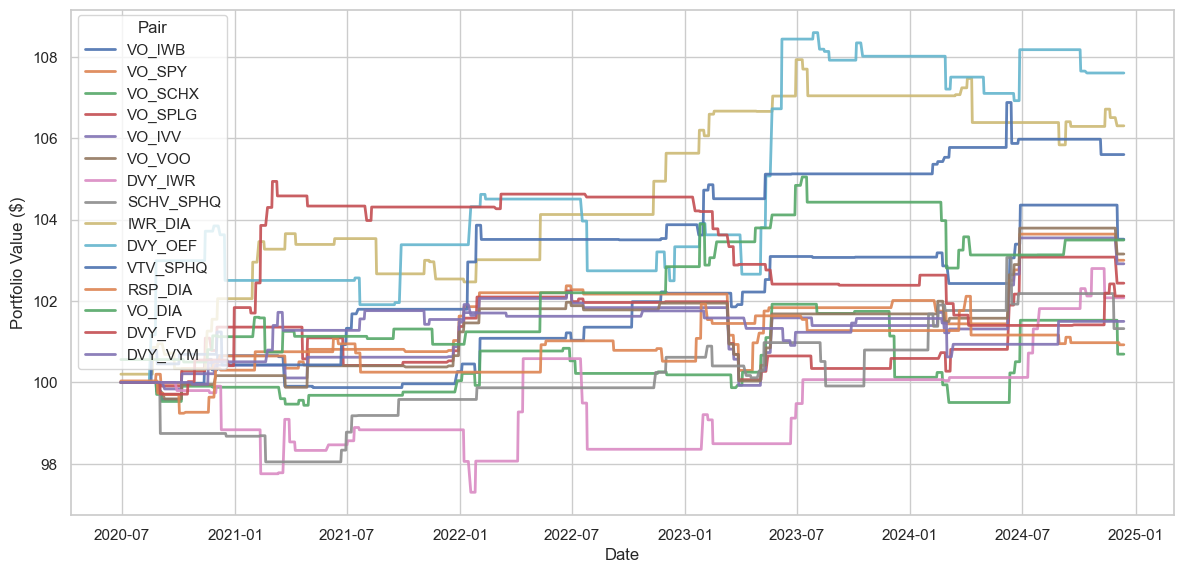

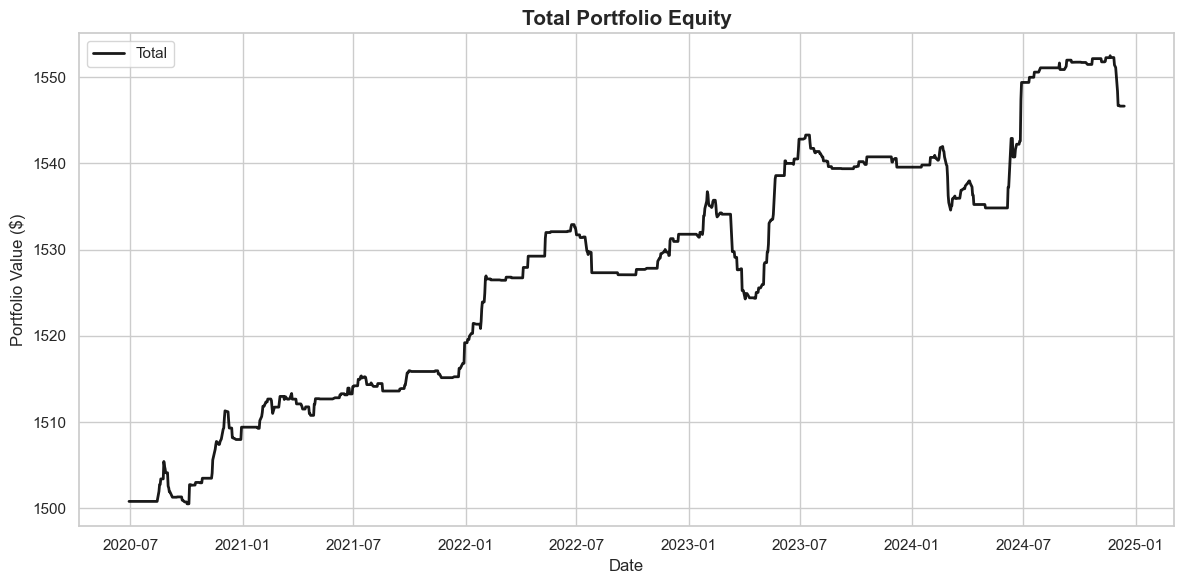

Summary
VO_IWB: Final Value = $103.52, Total Return = 3.52%, Trades = 34
VO_SPY: Final Value = $103.00, Total Return = 3.00%, Trades = 33
VO_SCHX: Final Value = $100.69, Total Return = 0.69%, Trades = 36
VO_SPLG: Final Value = $102.44, Total Return = 2.44%, Trades = 33
VO_IVV: Final Value = $102.91, Total Return = 2.91%, Trades = 27
VO_VOO: Final Value = $103.15, Total Return = 3.15%, Trades = 29
DVY_IWR: Final Value = $102.08, Total Return = 2.08%, Trades = 36
SCHV_SPHQ: Final Value = $101.32, Total Return = 1.32%, Trades = 29
IWR_DIA: Final Value = $106.30, Total Return = 6.09%, Trades = 44
DVY_OEF: Final Value = $107.60, Total Return = 7.60%, Trades = 39
VTV_SPHQ: Final Value = $105.60, Total Return = 5.60%, Trades = 29
RSP_DIA: Final Value = $100.92, Total Return = 0.89%, Trades = 32
VO_DIA: Final Value = $103.50, Total Return = 2.92%, Trades = 32
DVY_FVD: Final Value = $102.12, Total Return = 2.12%, Trades = 36
DVY_VYM: Final Value = $101.50, Total Return = 1.50%, Trades = 27

Tot

In [5]:
xgboost.run_simulation(etf_pairs, test_prices, pair_models, feature_cols, pair_betas)